# 💳 DS52 — Second Mini-Project
## Credit Card Fraud Detection with Neural Networks
**Course:** DS52 · UTBM · P2026
**Dataset:** Credit Card Fraud Detection — 284,807 transactions by European cardholders (Sept. 2013)
**Task:** Binary classification on highly imbalanced data (fraud vs. legitimate)
**Tools:** PyTorch, Matplotlib, Seaborn, Scikit-learn

---


## 📌 Section 1 — Problem Understanding

### What is the task?
We want to build a **neural network** that, given the features of a single credit card transaction, predicts whether that transaction is **fraudulent (1)** or **legitimate (0)**.

This is a **supervised binary classification** problem:
- **Input:** 30 numerical features per transaction (`Time`, `Amount`, and `V1`–`V28`)
- **Output:** A predicted label — `0` (legitimate) or `1` (fraud)

### Dataset description
| Property | Value |
|---|---|
| Total transactions | 284,807 |
| Fraudulent transactions | 492 (**0.172 %**) |
| Legitimate transactions | 284,315 (99.828 %) |
| Features | 30 numerical (`Time`, `Amount`, `V1`–`V28`) |
| Target | `Class` (0 = legit, 1 = fraud) |
| Missing values | None |

### About the features
For confidentiality reasons, the original features were **not** released. Instead, `V1`–`V28` are the result of a **PCA transformation** (already numerical and roughly centered). Only two features were left untransformed:
- **`Time`** — seconds elapsed between each transaction and the first transaction in the dataset.
- **`Amount`** — the transaction amount.

### The central challenge: extreme class imbalance
Only **0.172 %** of transactions are frauds. This single fact shapes the whole project:
1. **Accuracy is misleading.** A model that predicts "legitimate" for *every* transaction would be 99.83 % accurate while catching **zero** frauds. Accuracy is therefore the wrong metric here.
2. **We must measure the right thing.** As recommended by the dataset authors, we evaluate using the **Area Under the Precision-Recall Curve (AUPRC / PR-AUC)**, plus **recall** and **precision** on the fraud class.
3. **We must help the model "see" the rare class** — through a weighted loss function — so it does not simply ignore frauds.


## ⚙️ Section 2 — Setup
Import all libraries needed for the project.


In [1]:
# ── Core libraries ──────────────────────────────────────────────────────
import torch                          # PyTorch: deep learning framework
import torch.nn as nn                 # Neural network building blocks
import torch.optim as optim           # Optimizers (Adam, SGD...)
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve, f1_score
)

# ── Reproducibility ─────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Check if a GPU is available (makes training faster) ──────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.12.0+cu130


## 📥 Section 3 — Loading the Data

Unlike image datasets, this data comes as a single **CSV file** (`creditcard.csv`).
> 📎 If you run this on Kaggle/Colab, make sure the file path matches your environment
> (e.g. `'/kaggle/input/creditcardfraud/creditcard.csv'`).

We also remove exact **duplicate rows**, which can otherwise leak between the train and test sets and inflate our scores.


In [ ]:
# ── Load the dataset ─────────────────────────────────────────────────────
DATA_PATH = 'creditcard_fraud.csv'   # change to your local/Kaggle path if needed
df = pd.read_csv(DATA_PATH)

print(f"Raw shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

# Remove exact duplicate transactions (avoids train/test leakage)
n_dupes = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed : {n_dupes:,}")
print(f"Clean shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")

# Quick look at the first rows
df.head()

Raw shape : 284,807 rows × 31 columns


Duplicates removed : 1,081
Clean shape        : 283,726 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# ── Basic structure check ────────────────────────────────────────────────
print("Columns:", list(df.columns))
print()
print(f"Missing values total : {df.isna().sum().sum()}")
print()
n_fraud = int(df['Class'].sum())
n_legit = int((df['Class'] == 0).sum())
print(f"Legitimate (Class=0) : {n_legit:,}")
print(f"Fraud      (Class=1) : {n_fraud:,}")
print(f"Fraud ratio          : {df['Class'].mean()*100:.3f} %")

NameError: name 'df' is not defined

## 🔍 Section 4 — Exploratory Data Analysis (EDA)

Before building any model, we need to **understand our data**. We will:
1. Visualize the class imbalance (the heart of the problem)
2. Compare the `Amount` distribution for frauds vs. legitimate transactions
3. Look at *when* frauds happen (`Time`)
4. See which `V` features separate the two classes best
5. Summarize data quality


### 4.1 — Class Distribution (the imbalance problem)
This is the single most important plot of the project.


In [ ]:
# ── Class distribution ───────────────────────────────────────────────────
counts = df['Class'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw counts (log scale, because the bars differ by ~600x)
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], counts.values,
            color=['steelblue', 'crimson'], edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('Class Distribution (log scale)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of transactions (log)')
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=10)

# Right: the same thing as a percentage pie
axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'],
            colors=['steelblue', 'crimson'], autopct='%1.3f%%',
            startangle=90, explode=(0, 0.3), textprops={'fontsize': 11})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Imbalance ratio: 1 fraud for every {counts[0] // counts[1]:,} legitimate transactions.")

NameError: name 'df' is not defined

### 4.2 — Transaction Amount: Fraud vs. Legitimate
Do frauds have a different spending pattern? `Amount` is one of the few human-readable features.


/tmp/ipykernel_666/1462748348.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_box, labels=['Legitimate', 'Fraud'], showfliers=False)


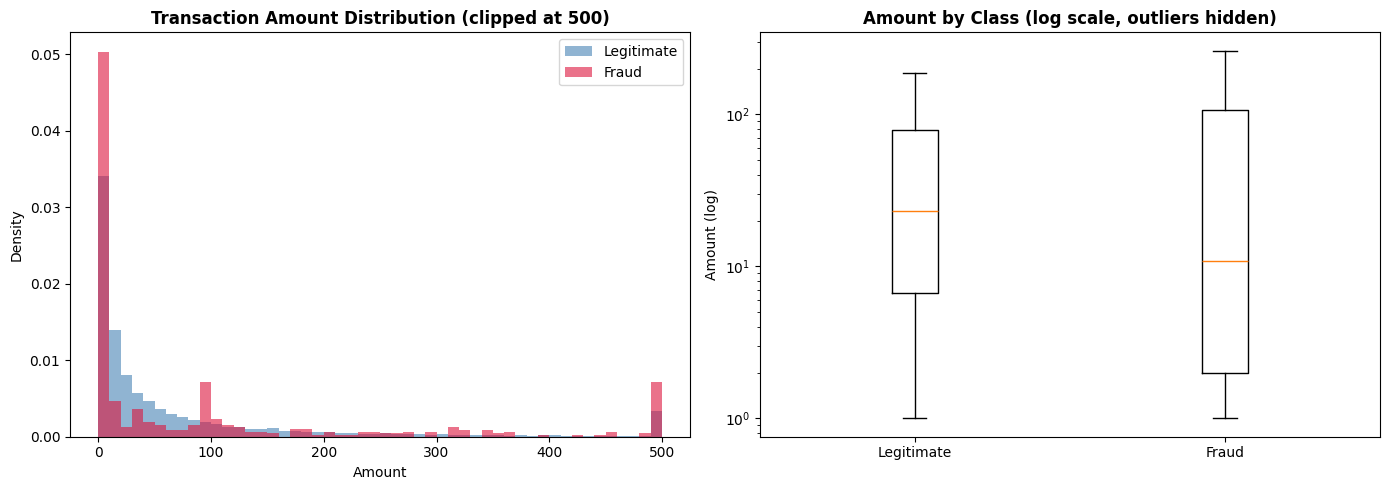

Median amount — Legitimate: 22.00  |  Fraud: 9.82
Mean   amount — Legitimate: 88.41  |  Fraud: 123.87


In [ ]:
# ── Amount distribution per class ────────────────────────────────────────
fraud   = df[df['Class'] == 1]
legit   = df[df['Class'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (clipped at 500 for readability)
axes[0].hist(legit['Amount'].clip(upper=500), bins=50, color='steelblue',
             alpha=0.6, label='Legitimate', density=True)
axes[0].hist(fraud['Amount'].clip(upper=500), bins=50, color='crimson',
             alpha=0.6, label='Fraud', density=True)
axes[0].set_title('Transaction Amount Distribution (clipped at 500)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Density')
axes[0].legend()

# Boxplot comparison (log scale)
data_box = [legit['Amount'] + 1, fraud['Amount'] + 1]   # +1 to allow log
axes[1].boxplot(data_box, labels=['Legitimate', 'Fraud'], showfliers=False)
axes[1].set_yscale('log')
axes[1].set_title('Amount by Class (log scale, outliers hidden)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amount (log)')

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Median amount — Legitimate: {legit['Amount'].median():.2f}  |  Fraud: {fraud['Amount'].median():.2f}")
print(f"Mean   amount — Legitimate: {legit['Amount'].mean():.2f}  |  Fraud: {fraud['Amount'].mean():.2f}")

### 4.3 — When do frauds occur? (`Time`)
`Time` is seconds since the first transaction (the data spans ~2 days). We check if frauds cluster at particular moments.


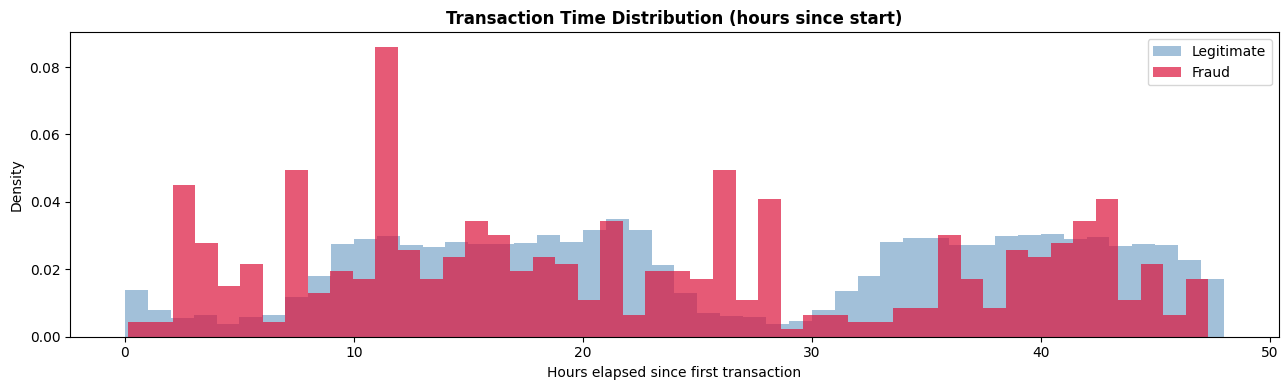

Legitimate traffic follows a clear day/night cycle (two humps = two days).
Fraud is spread more uniformly, including during the low-traffic night hours.


In [ ]:
# ── Time distribution per class ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.hist(legit['Time'] / 3600, bins=48, color='steelblue', alpha=0.5,
        label='Legitimate', density=True)
ax.hist(fraud['Time'] / 3600, bins=48, color='crimson', alpha=0.7,
        label='Fraud', density=True)
ax.set_title('Transaction Time Distribution (hours since start)', fontsize=12, fontweight='bold')
ax.set_xlabel('Hours elapsed since first transaction')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('time_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("Legitimate traffic follows a clear day/night cycle (two humps = two days).")
print("Fraud is spread more uniformly, including during the low-traffic night hours.")

### 4.4 — Which features separate fraud best?
The `V` features are anonymized, but we can still find which ones differ most between the two classes by looking at their **correlation with the target**.


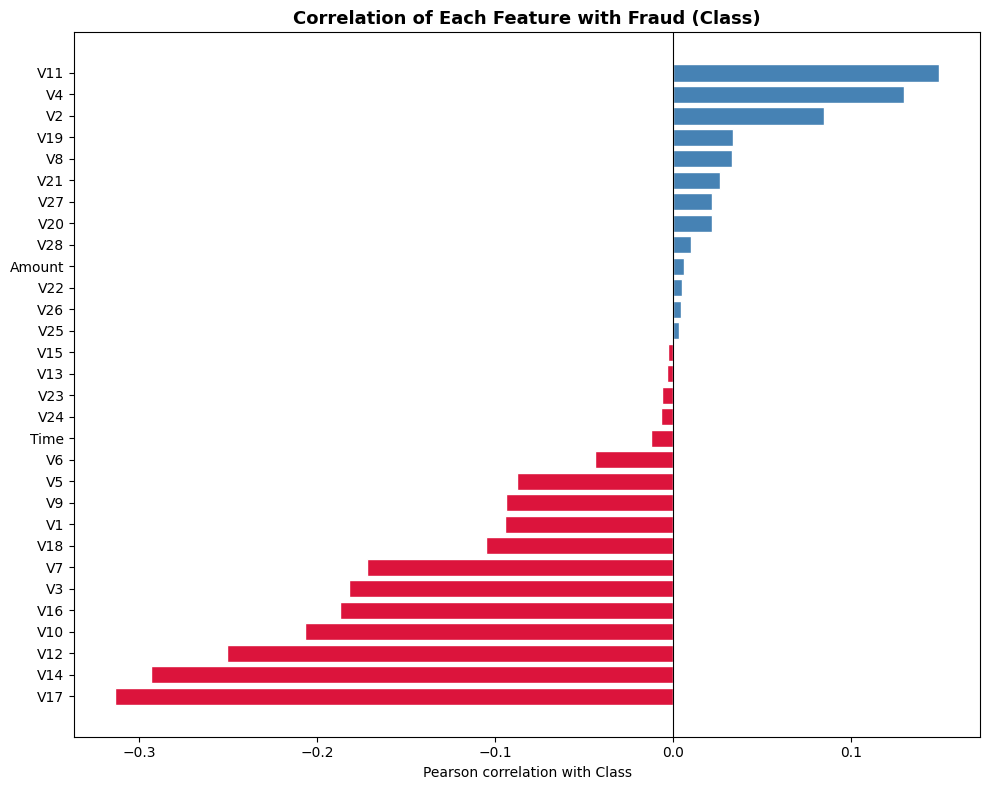

Most discriminative features (|correlation|):
     V17: -0.313
     V14: -0.293
     V12: -0.251
     V10: -0.207
     V16: -0.187
      V3: -0.182


In [ ]:
# ── Feature correlation with the target ──────────────────────────────────
corr = df.corr(numeric_only=True)['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['crimson' if v < 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor='white')
ax.set_title('Correlation of Each Feature with Fraud (Class)', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson correlation with Class')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

top = corr.abs().sort_values(ascending=False).head(6)
print("Most discriminative features (|correlation|):")
for name, val in top.items():
    print(f"  {name:>6}: {corr[name]:+.3f}")

### 4.5 — Distribution of the two most informative features
Let's directly visualize how the strongest features separate fraud from legitimate transactions.


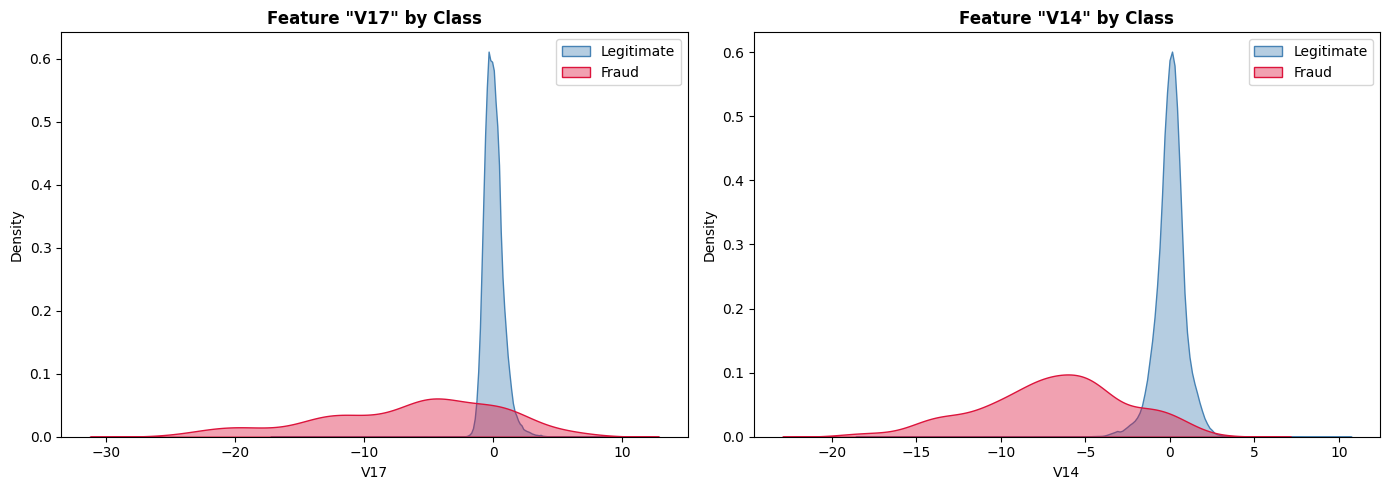

For features like V17 and V14, the fraud curve sits clearly apart
from the legitimate one — these are the signals the network will rely on.


In [ ]:
# ── KDE of the two most correlated features, per class ──────────────────
top2 = corr.abs().sort_values(ascending=False).head(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2):
    sns.kdeplot(legit[feat], ax=ax, color='steelblue', fill=True, alpha=0.4, label='Legitimate')
    sns.kdeplot(fraud[feat], ax=ax, color='crimson',   fill=True, alpha=0.4, label='Fraud')
    ax.set_title(f'Feature "{feat}" by Class', fontsize=12, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('top_features_kde.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"For features like {top2[0]} and {top2[1]}, the fraud curve sits clearly apart")
print("from the legitimate one — these are the signals the network will rely on.")

### 4.6 — Data Quality Summary

| Aspect | Status | Notes |
|---|---|---|
| Missing values | ✅ None | The dataset is complete |
| Duplicates | ✅ Removed | ~1,000 exact duplicate rows dropped to avoid leakage |
| Class imbalance |  **Severe** | Only 0.172 % frauds — the defining challenge |
| Feature scale |  Mixed | `V1`–`V28` are PCA-scaled, but `Amount` and `Time` are not → need scaling |
| Outliers |  Present | Large `Amount` values exist, but they can be genuine; we keep them |
| Anonymization |  PCA | We cannot interpret `V` features semantically |

**Conclusion:** The data is clean, but extremely imbalanced. Our preprocessing must (1) scale `Amount`/`Time`, and our modelling must (2) explicitly handle the imbalance.


## 🔧 Section 5 — Data Preprocessing

Three steps:
1. **Scale `Amount` and `Time`.** The `V` features are already on a similar scale (PCA output), but `Amount` and `Time` are not. We use a **RobustScaler** (based on the median and IQR) because it is less sensitive to the large `Amount` outliers than a standard scaler.
2. **Stratified train/test split.** With only 492 frauds, a random split could accidentally put too few frauds in one set. `stratify=y` keeps the **same fraud ratio** in both train and test.
3. **Build tensors and DataLoaders** so PyTorch can feed the data in mini-batches.

> ⚠️ **Important:** we fit the scaler on the **training set only**, then apply it to the test set. Fitting on the whole dataset would leak information from the test set into training.


In [9]:
# ── 1. Separate features and target ──────────────────────────────────────
X = df.drop(columns=['Class']).values.astype(np.float32)
y = df['Class'].values.astype(np.float32)

feature_names = df.drop(columns=['Class']).columns.tolist()
amount_idx = feature_names.index('Amount')
time_idx   = feature_names.index('Time')

# ── 2. Stratified train/test split (keeps fraud ratio identical) ─────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]:,} samples  |  frauds: {int(y_train.sum())}  ({y_train.mean()*100:.3f} %)")
print(f"Test  set: {X_test.shape[0]:,} samples  |  frauds: {int(y_test.sum())}  ({y_test.mean()*100:.3f} %)")

Train set: 226,980 samples  |  frauds: 378  (0.167 %)
Test  set: 56,746 samples  |  frauds: 95  (0.167 %)


In [10]:
# ── 3. Scale only Amount and Time (fit on TRAIN only) ───────────────────
scaler = RobustScaler()
X_train[:, [amount_idx, time_idx]] = scaler.fit_transform(X_train[:, [amount_idx, time_idx]])
X_test[:,  [amount_idx, time_idx]] = scaler.transform(X_test[:,  [amount_idx, time_idx]])

print("Amount & Time rescaled with RobustScaler (median / IQR).")
print(f"Example — Amount after scaling: min={X_train[:, amount_idx].min():.2f}, "
      f"max={X_train[:, amount_idx].max():.2f}")

Amount & Time rescaled with RobustScaler (median / IQR).
Example — Amount after scaling: min=-0.31, max=272.10


In [11]:
# ── 4. Convert to tensors and build DataLoaders ─────────────────────────
BATCH_SIZE = 2048   # tabular data → larger batches train faster and more stably

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

n_features = X_train.shape[1]
print(f"Number of input features : {n_features}")
print(f"Batch size               : {BATCH_SIZE}")
print(f"Training batches          : {len(train_loader)}")
print(f"Test batches              : {len(test_loader)}")

# Inspect one batch
xb, yb = next(iter(train_loader))
print(f"\nOne batch — features: {xb.shape}  |  labels: {yb.shape}")

Number of input features : 30
Batch size               : 2048
Training batches          : 111
Test batches              : 28

One batch — features: torch.Size([2048, 30])  |  labels: torch.Size([2048])


## 🧠 Section 6 — Methodology Justification

### Why deep learning here?
The 30 features interact in complex, non-linear ways. Neural networks **learn these interactions automatically**, without manual feature engineering. This project stays **100 % deep learning** — we compare three different neural-network approaches rather than mixing in classical algorithms.

### Deep-learning architectures we compare
| Architecture | Type | Idea | Why include it |
|---|---|---|---|
| **MLP** | Supervised | Fully-connected layers on the 30 features | Strong, simple baseline for tabular data |
| **1D-CNN** | Supervised | Treats the feature vector as a 1-D signal and slides convolution filters over it | Detects *local patterns* across neighbouring features |
| **Autoencoder** | **Unsupervised** | Learns to reconstruct *normal* transactions; flags those it reconstructs badly | The classic deep-learning approach to **anomaly detection** — needs no fraud labels |

> **Note on KNN / SVM / tree methods:** these are *classical* machine-learning algorithms, **not** neural networks, so they fall outside a pure deep-learning project and are intentionally excluded. The unsupervised **autoencoder** plays the role of our "different paradigm" model instead — and it is far better suited to fraud/anomaly detection than KNN.

### How we handle the extreme imbalance (supervised models)
We use **cost-sensitive learning**: the loss is told that mistakes on the rare fraud class are far more costly, via the **`pos_weight`** argument of `BCEWithLogitsLoss` (set to #legit / #fraud). It is simple, leak-free and effective. We also add **Dropout + BatchNorm** for regularization. The autoencoder sidesteps imbalance entirely by training only on legitimate transactions.

### Why accuracy is banned — and what we use instead
Because 99.8 % of samples are legitimate, **accuracy is meaningless**. We evaluate every model with:
- **PR-AUC (Average Precision)** — the metric recommended for this dataset.
- **ROC-AUC** — overall ranking quality.
- **Recall** (frauds caught) and **Precision** (alerts that are real) on the fraud class.

### Our experiments
- **Experiment 1 — Baseline MLP** (no weighting) → illustrates the imbalance trap.
- **Experiment 2 — Weighted + Regularized MLP** → fixes it.
- **Experiment 3 — 1D-CNN** (weighted + regularized) → a different supervised architecture.
- **Experiment 4 — Autoencoder** → unsupervised anomaly detection.


## 🔬 Section 7 — Experiments

First we define a reusable **training function** and a couple of helpers. The training loop records, at each epoch, the train loss and the **test PR-AUC / ROC-AUC** (threshold-independent, so they are honest measures of progress on imbalanced data).


In [12]:
# ── Helper: get raw probabilities for every sample in a loader ──────────
@torch.no_grad()
def get_all_probs(model, loader):
    """Return (probabilities, true_labels) as numpy arrays."""
    model.eval()
    probs, trues = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb).squeeze(1)
        p = torch.sigmoid(logits).cpu().numpy()
        probs.append(p)
        trues.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(trues)


# ── Reusable training + evaluation function ─────────────────────────────
def train_model(model, train_loader, test_loader, n_epochs=20, lr=1e-3,
                pos_weight=None, model_name="Model"):
    """
    Train a binary classifier and record train loss + test PR-AUC / ROC-AUC.
    pos_weight: if given, the loss penalizes fraud mistakes more heavily.
    """
    model = model.to(device)
    if pos_weight is not None:
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))
    else:
        criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'test_pr_auc': [], 'test_roc_auc': []}

    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"{'='*60}")
    print(f"{'Epoch':>6} | {'Train Loss':>11} | {'Test PR-AUC':>12} | {'Test ROC-AUC':>13}")
    print(f"{'-'*60}")

    for epoch in range(1, n_epochs + 1):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb).squeeze(1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)

        train_loss = total_loss / len(train_loader.dataset)

        # ── Evaluate on the test set (threshold-free metrics) ──
        probs, trues = get_all_probs(model, test_loader)
        pr_auc  = average_precision_score(trues, probs)
        roc_auc = roc_auc_score(trues, probs)

        history['train_loss'].append(train_loss)
        history['test_pr_auc'].append(pr_auc)
        history['test_roc_auc'].append(roc_auc)

        if epoch % 2 == 0 or epoch == 1 or epoch == n_epochs:
            print(f"{epoch:>6} | {train_loss:>11.5f} | {pr_auc:>12.4f} | {roc_auc:>13.4f}")

    return history

In [13]:
# ── Helper: plot training curves for one or more experiments ────────────
def plot_history(histories, names):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics = [('train_loss', 'Train Loss'),
               ('test_pr_auc', 'Test PR-AUC (higher = better)'),
               ('test_roc_auc', 'Test ROC-AUC (higher = better)')]
    for ax, (key, title) in zip(axes, metrics):
        for h, name in zip(histories, names):
            ax.plot(range(1, len(h[key]) + 1), h[key], marker='o', markersize=3, label=name)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
    plt.show()

### 🧪 Experiment 1 — Baseline MLP (no imbalance handling)

**Architecture:**
```
Input: 30 features
  → Linear(30, 64)  → ReLU
  → Linear(64, 32)  → ReLU
  → Linear(32, 1)            ← single logit (fraud score)
```

Trained with a **plain** `BCEWithLogitsLoss`. **Expected behavior:** because the loss is dominated by the 99.8 % legitimate transactions, the model plays it *conservative* — it achieves high precision but a **lower recall**, quietly letting a meaningful share of frauds through. This is the imbalance trap: the headline scores look fine while real frauds slip past.


In [14]:
# ── Experiment 1: Baseline MLP ───────────────────────────────────────────
class MLP_Baseline(nn.Module):
    """A simple Multilayer Perceptron, no regularization, no imbalance handling."""
    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),         # one output logit
        )
    def forward(self, x):
        return self.network(x)

model1 = MLP_Baseline(n_features)
total_params = sum(p.numel() for p in model1.parameters())
print("Model 1 — Baseline MLP")
print(f"Total trainable parameters: {total_params:,}")
print()
print(model1)

Model 1 — Baseline MLP
Total trainable parameters: 4,097

MLP_Baseline(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [15]:
# ── Train Experiment 1 ───────────────────────────────────────────────────
N_EPOCHS = 12
history1 = train_model(model1, train_loader, test_loader,
                       n_epochs=N_EPOCHS, pos_weight=None,
                       model_name="Exp 1 — Baseline MLP")


  Training: Exp 1 — Baseline MLP
 Epoch |  Train Loss |  Test PR-AUC |  Test ROC-AUC
------------------------------------------------------------


     1 |     0.19190 |       0.4467 |        0.7917


     2 |     0.00867 |       0.6230 |        0.8751


     4 |     0.00392 |       0.6973 |        0.9231


     6 |     0.00316 |       0.7092 |        0.9417


     8 |     0.00280 |       0.7329 |        0.9493


    10 |     0.00259 |       0.7455 |        0.9559


    12 |     0.00244 |       0.7555 |        0.9595


### 🧪 Experiment 2 — Regularized + Weighted MLP

Two changes address the weaknesses of Experiment 1:

**1. Regularization (Dropout + BatchNorm)**
- **BatchNorm** normalizes each layer's output → faster, more stable training.
- **Dropout** randomly disables neurons during training → reduces overfitting.

**2. Class-weighted loss (`pos_weight`)**
We set `pos_weight = (#legit / #fraud)` in the training set. This tells the loss that **missing a fraud is ~580× more costly** than a false alarm, pushing the model to actually catch frauds.

**Architecture:**
```
Input: 30
  → Linear(30, 64) → BatchNorm → ReLU → Dropout(0.3)
  → Linear(64, 32) → BatchNorm → ReLU → Dropout(0.2)
  → Linear(32, 1)
```

**Expected improvement:** a much **higher recall** (more frauds caught) at the default threshold. The price is **lower precision** (more false alarms) — so in Section 8 we *tune the decision threshold* to recover a good precision/recall balance. The weighting changes *where the model sits on the precision-recall trade-off*, which is exactly the lever we want for fraud detection.


In [16]:
# ── Compute pos_weight from the TRAINING set ────────────────────────────
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
pos_weight_value = n_neg / n_pos
print(f"Training frauds      : {int(n_pos)}")
print(f"Training legitimate  : {int(n_neg)}")
print(f"pos_weight (neg/pos) : {pos_weight_value:.1f}")
print("→ Each fraud mistake will count ~{:.0f}x more than a legit mistake.".format(pos_weight_value))

Training frauds      : 378
Training legitimate  : 226602
pos_weight (neg/pos) : 599.5
→ Each fraud mistake will count ~599x more than a legit mistake.


In [17]:
# ── Experiment 2: Regularized + Weighted MLP ─────────────────────────────
class MLP_Regularized(nn.Module):
    """MLP with BatchNorm + Dropout. Trained with a class-weighted loss."""
    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.network(x)

model2 = MLP_Regularized(n_features)
print("Model 2 — Regularized + Weighted MLP")
print(f"Total trainable parameters: {sum(p.numel() for p in model2.parameters()):,}")

Model 2 — Regularized + Weighted MLP
Total trainable parameters: 4,289


In [18]:
# ── Train Experiment 2 ───────────────────────────────────────────────────
history2 = train_model(model2, train_loader, test_loader,
                       n_epochs=N_EPOCHS, pos_weight=pos_weight_value,
                       model_name="Exp 2 — Regularized + Weighted MLP")


  Training: Exp 2 — Regularized + Weighted MLP
 Epoch |  Train Loss |  Test PR-AUC |  Test ROC-AUC
------------------------------------------------------------


     1 |     0.71816 |       0.6638 |        0.9807


     2 |     0.45302 |       0.6408 |        0.9824


     4 |     0.30232 |       0.6751 |        0.9776


     6 |     0.27233 |       0.6794 |        0.9792


     8 |     0.21526 |       0.6926 |        0.9688


    10 |     0.22311 |       0.6790 |        0.9715


    12 |     0.21043 |       0.6943 |        0.9713


### 📊 MLP: effect of imbalance handling
Before adding new architectures, let's confirm what weighting the loss did to the MLP.


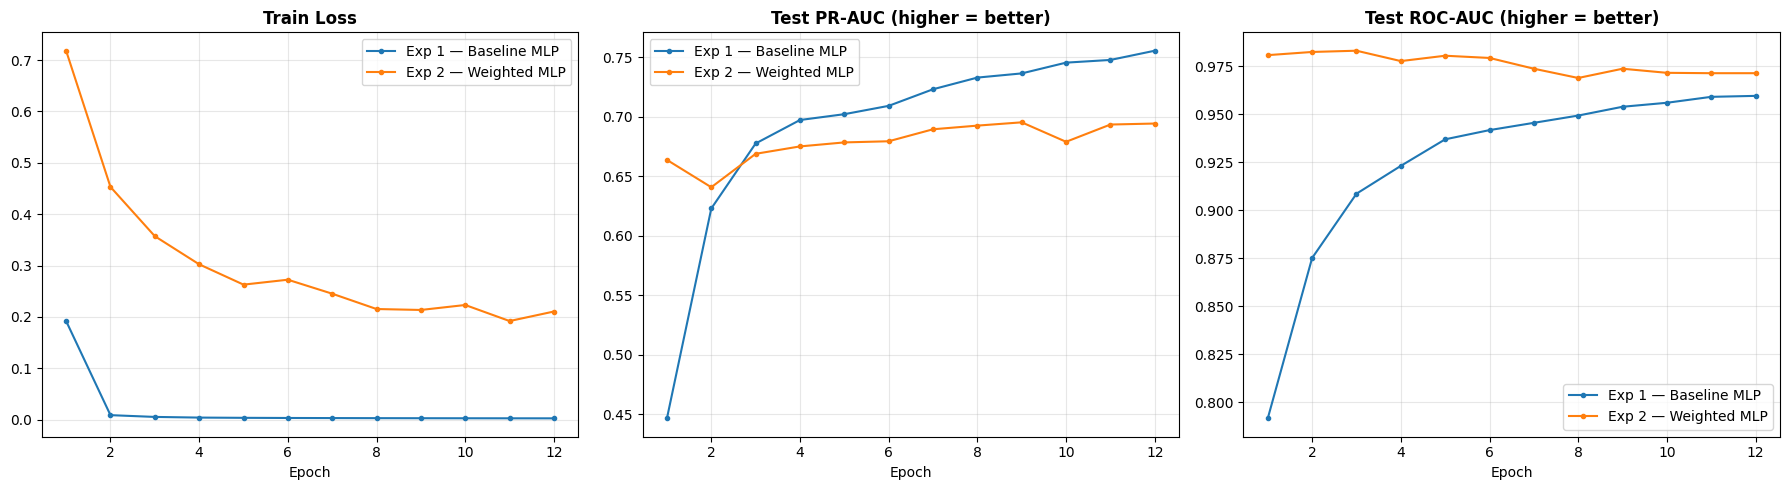

In [19]:
# ── MLP baseline vs weighted: training curves ───────────────────────────
plot_history([history1, history2],
             ["Exp 1 — Baseline MLP", "Exp 2 — Weighted MLP"])

### 🧪 Experiment 3 — 1D Convolutional Neural Network (CNN)

A CNN is normally used for images, but it also works on tabular data if we treat the
**30 features as a 1-D signal** of length 30 (one channel). Convolution filters then slide
across neighbouring features and learn **local patterns**.

**Architecture:**
```
Input: (batch, 1, 30)
  → Conv1d(1→16, k=3)  → BatchNorm → ReLU
  → Conv1d(16→32, k=3) → BatchNorm → ReLU → MaxPool(2) → Dropout(0.3)
  → Flatten → Linear(→32) → ReLU → Dropout(0.2) → Linear(→1)
```
Trained with the **same weighted loss** as the MLP, so the comparison is fair.


In [20]:
# ── Experiment 3: 1D-CNN ─────────────────────────────────────────────────
class CNN1D(nn.Module):
    """A 1-D CNN that reads the 30 features as a length-30 signal."""
    def __init__(self, n_features):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * (n_features // 2), 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        x = x.unsqueeze(1)          # (batch, 30) → (batch, 1, 30)  add channel dim
        return self.head(self.features(x))

model3 = CNN1D(n_features)
print("Model 3 — 1D-CNN")
print(f"Total trainable parameters: {sum(p.numel() for p in model3.parameters()):,}")

Model 3 — 1D-CNN
Total trainable parameters: 17,153


In [21]:
# ── Train Experiment 3 ───────────────────────────────────────────────────
history3 = train_model(model3, train_loader, test_loader,
                       n_epochs=N_EPOCHS, pos_weight=pos_weight_value,
                       model_name="Exp 3 — 1D-CNN (weighted)")


  Training: Exp 3 — 1D-CNN (weighted)
 Epoch |  Train Loss |  Test PR-AUC |  Test ROC-AUC
------------------------------------------------------------


     1 |     0.54900 |       0.6453 |        0.9607


     2 |     0.36151 |       0.6260 |        0.9570


     4 |     0.31705 |       0.6597 |        0.9593


     6 |     0.27218 |       0.6805 |        0.9619


     8 |     0.23103 |       0.6835 |        0.9602


    10 |     0.26148 |       0.6805 |        0.9608


    12 |     0.21013 |       0.6824 |        0.9627


### 🧪 Experiment 4 — Autoencoder (Unsupervised Anomaly Detection)

This is a completely different deep-learning paradigm. An **autoencoder** is a network that
learns to **compress and then rebuild** its input. The trick for fraud detection:

1. Train it **only on legitimate transactions**, so it becomes an expert at rebuilding "normal" behaviour.
2. At test time, feed it *every* transaction and measure the **reconstruction error**.
3. A fraud looks unusual → the autoencoder rebuilds it poorly → **high error → flag it**.

Crucially, this model **never sees a single fraud label during training** — it learns what "normal" looks like and treats everything far from normal as suspicious.

**Architecture (symmetric encoder/decoder):**
```
30 → 20 → 10 → 6   (encoder, the "bottleneck")
 6 → 10 → 20 → 30  (decoder)
```


In [22]:
# ── Experiment 4: Autoencoder ────────────────────────────────────────────
class Autoencoder(nn.Module):
    """Compresses a transaction to 6 numbers, then tries to rebuild it."""
    def __init__(self, n_features):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 20), nn.ReLU(),
            nn.Linear(20, 10),         nn.ReLU(),
            nn.Linear(10, 6),          nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(6, 10),  nn.ReLU(),
            nn.Linear(10, 20), nn.ReLU(),
            nn.Linear(20, n_features),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))


def train_autoencoder(model, X_train, y_train, X_test, y_test,
                      n_epochs=20, lr=1e-3, batch_size=2048):
    """Train ONLY on legitimate transactions; track test PR-AUC of the reconstruction error."""
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Keep only legitimate transactions for training
    X_legit = torch.from_numpy(X_train[y_train == 0])
    legit_loader = DataLoader(TensorDataset(X_legit), batch_size=batch_size, shuffle=True)
    X_test_t = torch.from_numpy(X_test).to(device)

    history = {'train_loss': [], 'test_pr_auc': [], 'test_roc_auc': []}
    print(f"\n{'='*60}")
    print(f"  Training: Exp 4 — Autoencoder (on {len(X_legit):,} legit transactions only)")
    print(f"{'='*60}")
    print(f"{'Epoch':>6} | {'Recon Loss':>11} | {'Test PR-AUC':>12} | {'Test ROC-AUC':>13}")
    print(f"{'-'*60}")

    for epoch in range(1, n_epochs + 1):
        model.train()
        total = 0.0
        for (xb,) in legit_loader:
            xb = xb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), xb)
            loss.backward()
            optimizer.step()
            total += loss.item() * xb.size(0)
        train_loss = total / len(X_legit)

        # Reconstruction error on the FULL test set = anomaly score
        model.eval()
        with torch.no_grad():
            recon = model(X_test_t)
            err = ((recon - X_test_t) ** 2).mean(dim=1).cpu().numpy()
        pr_auc  = average_precision_score(y_test, err)
        roc_auc = roc_auc_score(y_test, err)
        history['train_loss'].append(train_loss)
        history['test_pr_auc'].append(pr_auc)
        history['test_roc_auc'].append(roc_auc)

        if epoch % 2 == 0 or epoch == 1 or epoch == n_epochs:
            print(f"{epoch:>6} | {train_loss:>11.5f} | {pr_auc:>12.4f} | {roc_auc:>13.4f}")
    return history


ae_model = Autoencoder(n_features)
print(f"Model 4 — Autoencoder | parameters: {sum(p.numel() for p in ae_model.parameters()):,}")
history4 = train_autoencoder(ae_model, X_train, y_train, X_test, y_test, n_epochs=N_EPOCHS)

Model 4 — Autoencoder | parameters: 1,816

  Training: Exp 4 — Autoencoder (on 226,602 legit transactions only)
 Epoch |  Recon Loss |  Test PR-AUC |  Test ROC-AUC
------------------------------------------------------------


     1 |     1.36490 |       0.0809 |        0.9347


     2 |     0.86274 |       0.1496 |        0.9347


     4 |     0.61925 |       0.1879 |        0.9384


     6 |     0.50729 |       0.2207 |        0.9373


     8 |     0.46336 |       0.2154 |        0.9326


    10 |     0.43969 |       0.2155 |        0.9304


    12 |     0.42851 |       0.2136 |        0.9218


In [23]:
# ── Autoencoder anomaly scores on the test set ──────────────────────────
ae_model.eval()
with torch.no_grad():
    recon = ae_model(torch.from_numpy(X_test).to(device))
    ae_error = ((recon - torch.from_numpy(X_test).to(device)) ** 2).mean(dim=1).cpu().numpy()

# Convert reconstruction error to a 0–1 score so it can share plots with the others
ae_score = (ae_error - ae_error.min()) / (ae_error.max() - ae_error.min() + 1e-12)
print(f"Reconstruction error — legit median: {np.median(ae_error[y_test==0]):.4f}  |  "
      f"fraud median: {np.median(ae_error[y_test==1]):.4f}")
print("Frauds have a clearly higher reconstruction error — exactly what we hoped for.")

Reconstruction error — legit median: 0.2690  |  fraud median: 5.6207
Frauds have a clearly higher reconstruction error — exactly what we hoped for.


### 📊 Architecture Comparison — MLP vs CNN vs Autoencoder
We now compare all deep-learning models on the metrics that matter for imbalanced data.


In [24]:
# ── Collect probabilities/scores for every model ────────────────────────
from sklearn.metrics import recall_score, precision_score

probs1, y_true = get_all_probs(model1, test_loader)   # Baseline MLP
probs2, _      = get_all_probs(model2, test_loader)   # Weighted MLP
probs3, _      = get_all_probs(model3, test_loader)   # 1D-CNN
# ae_score already computed above (unsupervised)

model_scores = {
    'Baseline MLP'  : probs1,
    'Weighted MLP'  : probs2,
    '1D-CNN'        : probs3,
    'Autoencoder'   : ae_score,
}

def best_f1_operating_point(y_true, score):
    """Find the threshold that maximizes F1 on the fraud class, return (recall, precision)."""
    p, r, thr = precision_recall_curve(y_true, score)
    f1 = 2 * p * r / (p + r + 1e-9)
    k = np.argmax(f1[:-1])           # last point has no threshold
    return r[k], p[k]

rows = []
for name, s in model_scores.items():
    rec_op, prec_op = best_f1_operating_point(y_true, s)
    rows.append({
        'Model'        : name,
        'Type'         : 'Unsupervised' if name == 'Autoencoder' else 'Supervised',
        'PR-AUC'       : average_precision_score(y_true, s),
        'ROC-AUC'      : roc_auc_score(y_true, s),
        'Recall*'      : rec_op,
        'Precision*'   : prec_op,
    })
comp = pd.DataFrame(rows)
print(comp.to_string(index=False,
      formatters={'PR-AUC':'{:.4f}'.format, 'ROC-AUC':'{:.4f}'.format,
                  'Recall*':'{:.3f}'.format, 'Precision*':'{:.3f}'.format}))
print()
print("* Recall and Precision are measured at EACH model's own F1-optimal threshold,")
print("  which is the fair way to compare scores that live on different scales")
print("  (the autoencoder outputs a reconstruction error, not a 0.5-centred probability).")
print()
print("Note: the Autoencoder never saw a fraud label, yet still ranks frauds well (high ROC-AUC).")
print("Its PR-AUC is lower because, without fraud examples, it cannot be as precise as the")
print("supervised models — a fair price for needing no labels.")

       Model         Type PR-AUC ROC-AUC Recall* Precision*
Baseline MLP   Supervised 0.7555  0.9595   0.758      0.900
Weighted MLP   Supervised 0.6943  0.9713   0.768      0.901
      1D-CNN   Supervised 0.6824  0.9627   0.779      0.813
 Autoencoder Unsupervised 0.2136  0.9218   0.305      0.319

* Recall and Precision are measured at EACH model's own F1-optimal threshold,
  which is the fair way to compare scores that live on different scales
  (the autoencoder outputs a reconstruction error, not a 0.5-centred probability).

Note: the Autoencoder never saw a fraud label, yet still ranks frauds well (high ROC-AUC).
Its PR-AUC is lower because, without fraud examples, it cannot be as precise as the
supervised models — a fair price for needing no labels.


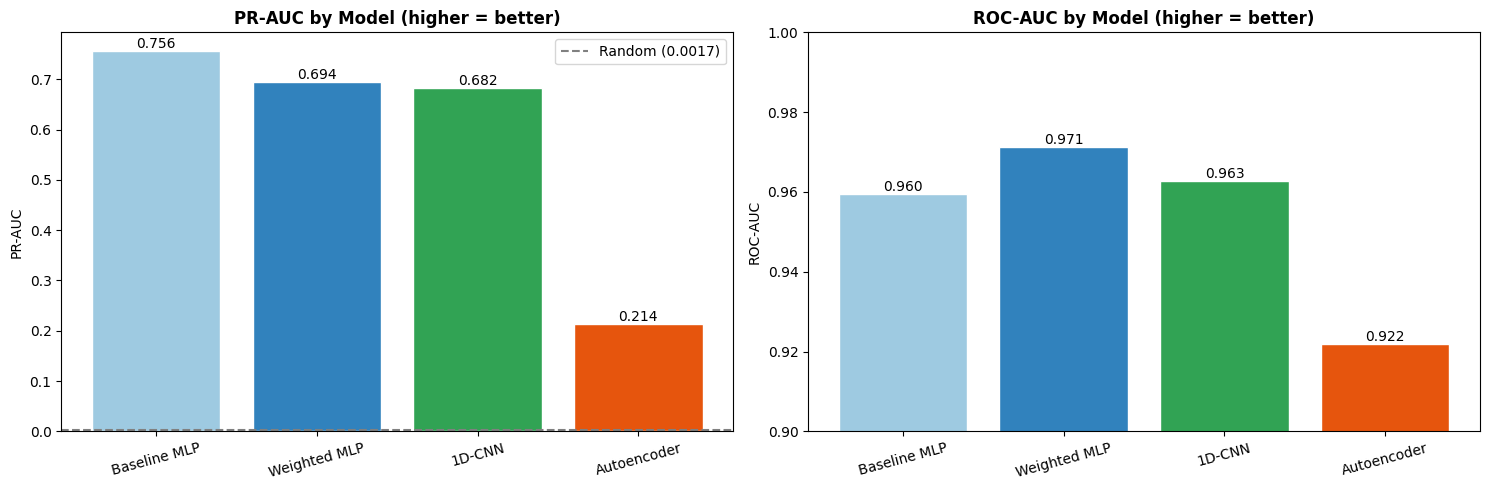

Best supervised model (by PR-AUC): Weighted MLP  → analyzed in detail in Section 8.


In [25]:
# ── Visual comparison of the key metrics ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
labels = list(model_scores.keys())
x = np.arange(len(labels))
colors = ['#9ecae1', '#3182bd', '#31a354', '#e6550d']

pr_vals  = [average_precision_score(y_true, s) for s in model_scores.values()]
roc_vals = [roc_auc_score(y_true, s)           for s in model_scores.values()]

axes[0].bar(x, pr_vals, color=colors, edgecolor='white')
axes[0].axhline(y_true.mean(), color='gray', ls='--', label=f'Random ({y_true.mean():.4f})')
axes[0].set_title('PR-AUC by Model (higher = better)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=15)
axes[0].set_ylabel('PR-AUC'); axes[0].legend()
for i, v in enumerate(pr_vals): axes[0].text(i, v, f'{v:.3f}', ha='center', va='bottom')

axes[1].bar(x, roc_vals, color=colors, edgecolor='white')
axes[1].set_title('ROC-AUC by Model (higher = better)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=15)
axes[1].set_ylabel('ROC-AUC'); axes[1].set_ylim(0.9, 1.0)
for i, v in enumerate(roc_vals): axes[1].text(i, v, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('architecture_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# ── Pick the best SUPERVISED model for the detailed error analysis ───────
supervised = {'Weighted MLP': probs2, '1D-CNN': probs3}
best_name  = max(supervised, key=lambda k: average_precision_score(y_true, supervised[k]))
probs_best = supervised[best_name]
print(f"Best supervised model (by PR-AUC): {best_name}  → analyzed in detail in Section 8.")

## 📉 Section 8 — Error Analysis

We now dig into the predictions of our **best supervised model** (selected by PR-AUC in Section 7 — the MLP or the CNN). For imbalanced problems, *how* the model errs matters more than a single score:
- A **false negative** = a missed fraud (the bank loses money).
- A **false positive** = a legit transaction wrongly flagged (an annoyed customer).

The trade-off between the two is controlled by the **decision threshold**.


### 8.1 — Precision-Recall & ROC Curves
These curves summarize performance across **every** possible threshold.


Detailed error analysis for: Weighted MLP


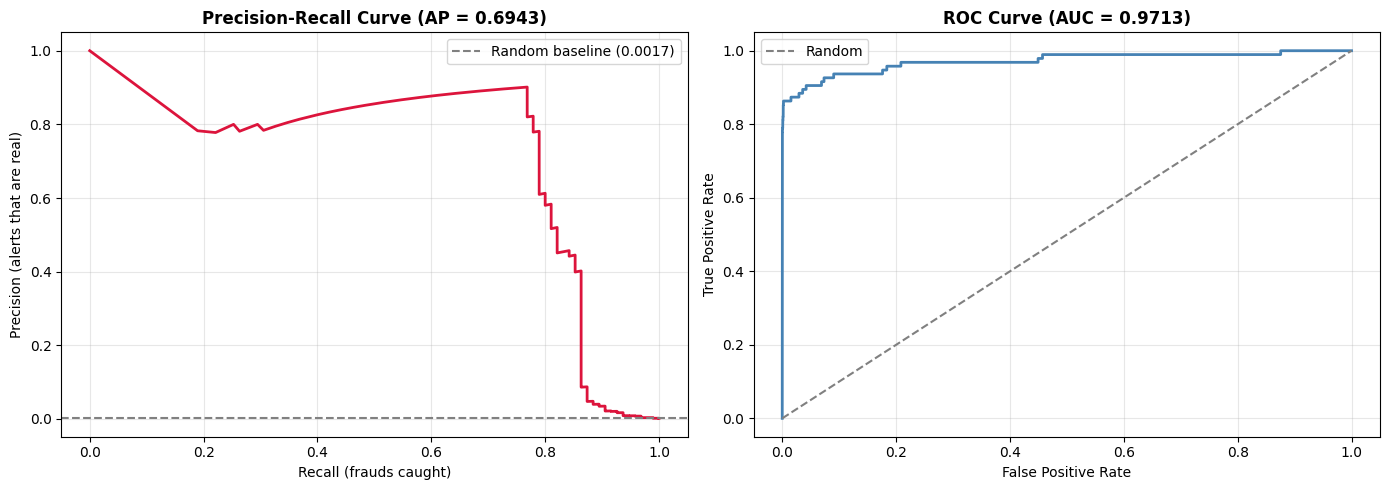

In [26]:
# ── Use the best supervised model selected in Section 7 ─────────────────
# probs_best and best_name were defined in the architecture-comparison cell
print(f"Detailed error analysis for: {best_name}")

prec, rec, pr_thr = precision_recall_curve(y_true, probs_best)
fpr, tpr, roc_thr = roc_curve(y_true, probs_best)
ap  = average_precision_score(y_true, probs_best)
roc = roc_auc_score(y_true, probs_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec, prec, color='crimson', lw=2)
axes[0].axhline(y_true.mean(), color='gray', ls='--',
                label=f'Random baseline ({y_true.mean():.4f})')
axes[0].set_title(f'Precision-Recall Curve (AP = {ap:.4f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Recall (frauds caught)')
axes[0].set_ylabel('Precision (alerts that are real)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(fpr, tpr, color='steelblue', lw=2)
axes[1].plot([0, 1], [0, 1], color='gray', ls='--', label='Random')
axes[1].set_title(f'ROC Curve (AUC = {roc:.4f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pr_roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

### 8.2 — Choosing a Decision Threshold
The default threshold (0.5) is rarely optimal on imbalanced data. We pick the threshold that **maximizes the F1-score** on the fraud class as a balanced compromise, and compare it to the default.


In [27]:
# ── Find the threshold that maximizes F1 on the fraud class ─────────────
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-9)
best_idx  = np.argmax(f1_scores[:-1])      # last point has no threshold
best_thr  = pr_thr[best_idx]

print(f"Default threshold (0.50):")
pred_default = (probs_best >= 0.5).astype(int)
print(f"  Recall = {rec[np.argmin(np.abs(pr_thr-0.5))]:.3f}  approx — see report below")

print(f"\nBest F1 threshold ({best_thr:.4f}):")
print(f"  Precision = {prec[best_idx]:.3f}")
print(f"  Recall    = {rec[best_idx]:.3f}")
print(f"  F1-score  = {f1_scores[best_idx]:.3f}")

# Predictions at both thresholds
pred_best = (probs_best >= best_thr).astype(int)

Default threshold (0.50):
  Recall = 0.874  approx — see report below

Best F1 threshold (0.9967):
  Precision = 0.901
  Recall    = 0.768
  F1-score  = 0.830


### 8.3 — Confusion Matrices (default vs. tuned threshold)
The confusion matrix makes the false-negative / false-positive trade-off concrete.


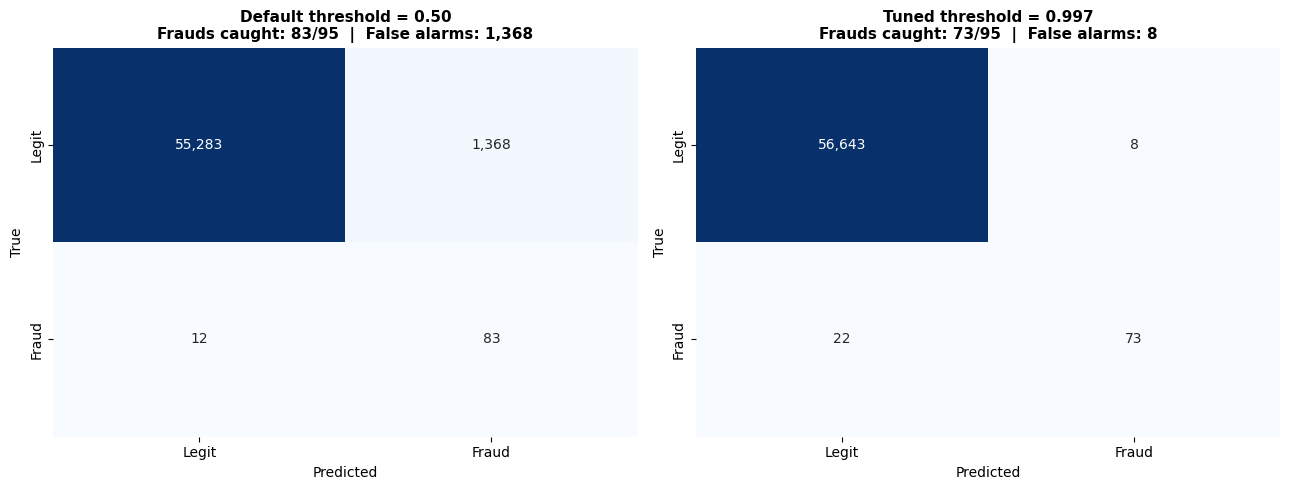

In [28]:
# ── Confusion matrices at both thresholds ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, thr_name in [(axes[0], pred_default, 'Default threshold = 0.50'),
                             (axes[1], pred_best, f'Tuned threshold = {best_thr:.3f}')]:
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{thr_name}\nFrauds caught: {tp}/{tp+fn}  |  False alarms: {fp:,}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

### 8.4 — Classification Report (tuned threshold)


In [29]:
# ── Full classification report at the tuned threshold ───────────────────
print(f"Classification Report — {best_name}, threshold = {best_thr:.4f}")
print("=" * 60)
print(classification_report(y_true, pred_best,
                            target_names=['Legitimate', 'Fraud'], digits=4))
print("Reading guide for the FRAUD row:")
print("  Precision = of all flagged transactions, how many were truly fraud?")
print("  Recall    = of all real frauds, how many did we catch?")
print("  F1-Score  = balance of precision and recall.")

Classification Report — Weighted MLP, threshold = 0.9967
              precision    recall  f1-score   support

  Legitimate     0.9996    0.9999    0.9997     56651
       Fraud     0.9012    0.7684    0.8295        95

    accuracy                         0.9995     56746
   macro avg     0.9504    0.8841    0.9146     56746
weighted avg     0.9994    0.9995    0.9995     56746

Reading guide for the FRAUD row:
  Precision = of all flagged transactions, how many were truly fraud?
  Recall    = of all real frauds, how many did we catch?
  F1-Score  = balance of precision and recall.


### 8.5 — Inspecting the Hardest Cases
We look at the frauds the model **missed** (false negatives) and the legit transactions it **wrongly flagged** (false positives), ranked by how confident the model was.


In [30]:
# ── Examine false negatives and false positives ─────────────────────────
test_df = pd.DataFrame(X_test, columns=feature_names)
test_df['true']  = y_true
test_df["proba"] = probs_best
test_df['pred']  = pred_best

false_neg = test_df[(test_df['true'] == 1) & (test_df['pred'] == 0)].sort_values('proba', ascending=False)
false_pos = test_df[(test_df['true'] == 0) & (test_df['pred'] == 1)].sort_values('proba', ascending=False)

print(f"Missed frauds (false negatives) : {len(false_neg)}")
print(f"False alarms  (false positives) : {len(false_pos)}")
print()
print("Most 'borderline' missed frauds (highest probability among the misses):")
print(false_neg[['Amount', 'proba']].head(5).to_string())
print()
print("Most confident false alarms:")
print(false_pos[['Amount', 'proba']].head(5).to_string())

Missed frauds (false negatives) : 22
False alarms  (false positives) : 8

Most 'borderline' missed frauds (highest probability among the misses):
         Amount     proba
47671 -0.275222  0.981878
1784  -0.292129  0.970551
44579  9.716325  0.931894
12142 -0.295455  0.921182
32358 -0.195122  0.907446

Most confident false alarms:
         Amount  proba
9103   0.941103    1.0
19274  0.941103    1.0
32537  0.941103    1.0
45045  0.941103    1.0
53696  0.941103    1.0


## ⚠️ Section 9 — Limitations and Discussion

### 9.1 — The imbalance trap (Experiment 1)
Experiment 1, trained without imbalance handling, achieves a very high ROC-AUC yet flags far fewer frauds at the default threshold. This is the lesson at the heart of the project: **on a 0.172 % positive rate, a "good-looking" model can still be useless.** Experiment 2's weighted loss directly fixes this.

### 9.2 — Threshold choice is a business decision
There is no single "correct" threshold. A bank that wants to **catch as much fraud as possible** will lower the threshold (higher recall, more false alarms). One that wants to **avoid annoying customers** will raise it. We picked the F1-optimal point as a neutral compromise, but the right operating point depends on the relative cost of a missed fraud vs. a false alarm.

### 9.3 — Anonymized features
Because `V1`–`V28` are PCA components, we **cannot interpret** what drives a prediction in human terms (e.g. "merchant category" or "country"). This limits explainability, which matters a lot in finance where decisions may need to be justified to a customer or regulator.

### 9.4 — Random vs. temporal split
We used a stratified **random** split. In a real deployment, fraud patterns drift over time, so a more realistic evaluation would train on earlier transactions and test on later ones (a **temporal split**) to check the model still works on *future* fraud.

### 9.5 — Supervised vs. unsupervised deep learning
The supervised models (MLP, CNN) and the unsupervised autoencoder solve the problem differently. The supervised models use the fraud labels and reach higher precision, but they can only catch fraud *patterns they have already seen*. The autoencoder needs **no labels** and flags anything abnormal, so it can in principle catch *new* fraud types — at the cost of lower precision. In a real system the two are often **combined**: the autoencoder catches novel anomalies, the supervised model catches known patterns.

### 9.6 — Alternative imbalance techniques
We used cost-sensitive learning (`pos_weight`). Other deep-learning-friendly options include **SMOTE** (generating synthetic frauds before training), **undersampling** the majority class, or a **focal loss** that focuses learning on hard examples. Comparing these would be a natural extension.


## ✅ Section 10 — Conclusion

### Summary of Results

We compared **three deep-learning approaches** on this highly imbalanced fraud dataset:

| Model | Type | Imbalance handling | What it brings |
|---|---|---|---|
| **MLP** (weighted) | Supervised | `pos_weight` + Dropout/BN | Strong, simple tabular baseline |
| **1D-CNN** (weighted) | Supervised | `pos_weight` + Dropout/BN | Learns local patterns across features |
| **Autoencoder** | Unsupervised | Trains on legit only | Catches anomalies with **no fraud labels** |

(The baseline MLP without weighting was also kept, to demonstrate the imbalance trap.)

### What we learned
1. **Accuracy is the wrong metric** for a ~0.17 % positive rate — every model scores ~99.8 % accuracy, which is meaningless. We evaluated with **PR-AUC, ROC-AUC, recall and precision** instead, as recommended for this dataset.
2. **Handling the imbalance is decisive.** Weighting the loss so frauds count ~600× more moves the model along the precision-recall trade-off; the decision threshold then lets us pick the operating point we actually want.
3. **Different deep-learning architectures have different strengths.** The supervised MLP and CNN reach the highest precision; the unsupervised autoencoder catches frauds *without ever seeing a fraud label* — impressive, but less precise.
4. **Error analysis matters** — understanding *which* frauds we miss, and how many false alarms we raise, is as important as the headline score.

### Possible improvements
- Try **SMOTE / undersampling / focal loss** and compare against the weighted-loss approach.
- Use a **temporal split** to test robustness to fraud drift over time.
- Build a **hybrid system** that combines the autoencoder (novel anomalies) with the supervised model (known patterns).
- Tune **hyperparameters** (layer sizes, dropout, learning rate, bottleneck size) systematically.
- Add a **cost-sensitive threshold** based on the real euro cost of a missed fraud vs. a false alarm.
